<a href="https://colab.research.google.com/github/jerinSabrina/Time_Series_project/blob/main/Data_Mining_Cup_Course/3_dmc_timeseries_baseline_sarimax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Pipeline — Baselines + SARIMAX

Workflow used in this notebook:

1. Load and prepare merged daily data
2. Check stationarity on the raw target only
3. Apply ACF/PACF directly on the raw stationary series
4. Create ACF/PACF-supported lag features, calendar features, and Masse features
5. Evaluate baseline models for 14-day and 30-day horizons
6. Train and evaluate SARIMA/SARIMAX models

No differencing and no decomposition are applied because the raw target is treated as stationary.

## 0. Imports and configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===============================
# Basic settings
# ===============================
TARGET_COL = "1"
FREQ = "D"
SEASON = 7
HORIZONS = [14, 30]
N_WINDOWS = 5
OUTPUT_DIR = "outputs"

TRAIN_START = "2020-03-02"
TRAIN_END   = "2023-12-31"
TEST_START  = "2024-01-01"
TEST_END    = "2024-12-31"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Colab path first, local fallback second.
BALE_FILE_COLAB = "/content/drive/MyDrive/Colab Notebooks/time series/ballengewichte_studenten.csv"
MASS_FILE_COLAB = "/content/drive/MyDrive/Colab Notebooks/time series/eingangsbandwaage_studenten.csv"

BALE_FILE_LOCAL = "/mnt/data/ballengewichte_studenten.csv"
MASS_FILE_LOCAL = "/mnt/data/eingangsbandwaage_studenten.csv"

BALE_FILE = BALE_FILE_COLAB if Path(BALE_FILE_COLAB).exists() else BALE_FILE_LOCAL
MASS_FILE = MASS_FILE_COLAB if Path(MASS_FILE_COLAB).exists() else MASS_FILE_LOCAL

print("BALE_FILE:", BALE_FILE)
print("MASS_FILE:", MASS_FILE)

BALE_FILE: /content/drive/MyDrive/Colab Notebooks/time series/ballengewichte_studenten.csv
MASS_FILE: /content/drive/MyDrive/Colab Notebooks/time series/eingangsbandwaage_studenten.csv


## 1. Load, merge, reindex, and split data

In [ ]:
# Load data
df_ballen = pd.read_csv(BALE_FILE, parse_dates=["Datum"])
df_band = pd.read_csv(MASS_FILE, parse_dates=["Zeitstempel"])
df_band = df_band.rename(columns={"Zeitstempel": "Datum"})

print("Input date range:")
print(df_band["Datum"].min(), "to", df_band["Datum"].max())
print()
print("Fraction date range:")
print(df_ballen["Datum"].min(), "to", df_ballen["Datum"].max())

# Inner join: keeps only dates available in both datasets.
df = df_band.merge(df_ballen, on="Datum", how="inner")
df["Datum"] = pd.to_datetime(df["Datum"])
df = df.sort_values("Datum").reset_index(drop=True)

print()
print("Merged date range after inner join:")
print(df["Datum"].min(), "to", df["Datum"].max())

# Complete daily date index.
full_dates = pd.date_range(df["Datum"].min(), df["Datum"].max(), freq=FREQ)
df = df.set_index("Datum").reindex(full_dates)
df.index.name = "Datum"
df = df.reset_index()

# Fill missing daily gaps.
# Important: this is acceptable for simple project work, but in strict forecasting,
# train/test imputation should be handled more carefully to avoid future leakage.
df[TARGET_COL] = df[TARGET_COL].interpolate("linear").ffill().bfill()
df["Masse"] = df["Masse"].interpolate("linear").ffill().bfill()

# Train/test split by date.
train_raw = df[(df["Datum"] >= TRAIN_START) & (df["Datum"] <= TRAIN_END)].copy()
test_raw = df[(df["Datum"] >= TEST_START) & (df["Datum"] <= TEST_END)].copy()

print()
print("Train range:", train_raw["Datum"].min(), "to", train_raw["Datum"].max(), "| rows:", len(train_raw))
print("Test range :", test_raw["Datum"].min(), "to", test_raw["Datum"].max(), "| rows:", len(test_raw))

if train_raw.empty or test_raw.empty:
    raise ValueError("Train or test split is empty. Check date ranges and input data.")

Input date range:
2019-10-24 00:00:00 to 2024-12-31 00:00:00

Fraction date range:
2020-03-02 00:00:00 to 2024-12-31 00:00:00

Merged date range after inner join:
2020-03-02 00:00:00 to 2024-12-31 00:00:00

Train range: 2020-03-02 00:00:00 to 2023-12-31 00:00:00 | rows: 1400
Test range : 2024-01-01 00:00:00 to 2024-12-31 00:00:00 | rows: 366


## 2. Raw data overview

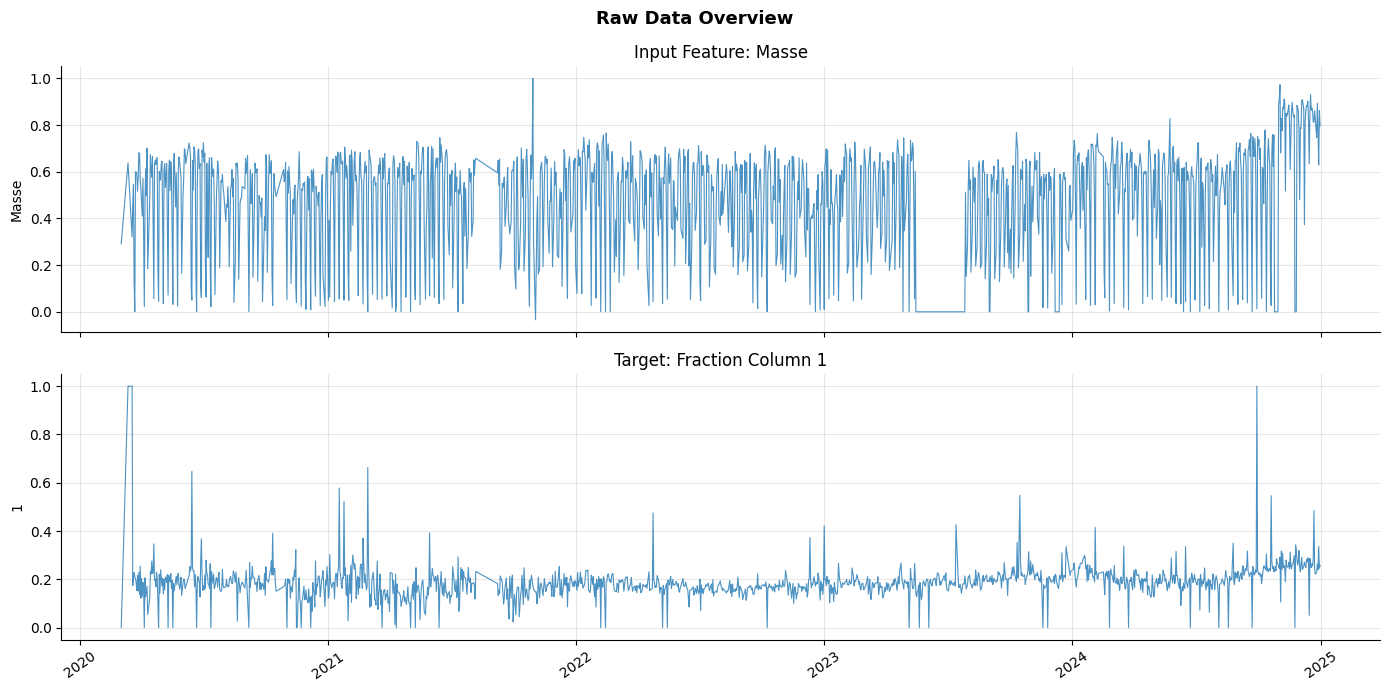

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle("Raw Data Overview", fontsize=13, fontweight="bold")

axes[0].plot(df["Datum"], df["Masse"], lw=0.8, alpha=0.8)
axes[0].set_title("Input Feature: Masse")
axes[0].set_ylabel("Masse")
axes[0].grid(True, alpha=0.3)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].plot(df["Datum"], df[TARGET_COL], lw=0.8, alpha=0.8)
axes[1].set_title(f"Target: Fraction Column {TARGET_COL}")
axes[1].set_ylabel(TARGET_COL)
axes[1].grid(True, alpha=0.3)
axes[1].spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/raw_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Stationarity check on raw target only

No differencing is applied in this notebook. The stationarity test is used only to document that the raw target can be modeled directly.

In [ ]:
def stationarity_check(series, label="series"):
    series = pd.Series(series).dropna()

    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")

    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan

    adf_result = "stationary" if adf_p < 0.05 else "non-stationary"
    kpss_result = "stationary" if kpss_p > 0.05 else "non-stationary"

    if adf_p < 0.05 and (np.isnan(kpss_p) or kpss_p > 0.05):
        verdict = "Raw series is acceptable as stationary. No differencing applied."
    elif adf_p < 0.05 and kpss_p <= 0.05:
        verdict = "Mixed result. You decided to keep raw data, so no differencing is applied."
    else:
        verdict = "ADF does not confirm stationarity. Re-check before final report."

    print("=" * 70)
    print(f"Stationarity check: {label}")
    print(f"ADF : stat={adf_stat:.5f}, p-value={adf_p:.5f} -> {adf_result}")
    print(f"KPSS: stat={kpss_stat:.5f}, p-value={kpss_p:.5f} -> {kpss_result}")
    print("Decision:", verdict)
    print("=" * 70)

    return {"ADF_stat": adf_stat, "ADF_p": adf_p, "KPSS_stat": kpss_stat, "KPSS_p": kpss_p, "verdict": verdict}

stationarity_result = stationarity_check(train_raw[TARGET_COL], label=f"Target column {TARGET_COL} | training data")

Stationarity check: Target column 1 | training data
ADF : stat=-8.86392, p-value=0.00000 -> stationary
KPSS: stat=0.32727, p-value=0.10000 -> stationary
Decision: Raw series is acceptable as stationary. No differencing applied.


/tmp/ipykernel_6878/1607103502.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")


## 4. Direct ACF/PACF on raw data

Because the raw target is treated as stationary, ACF and PACF are applied directly on the raw training target. No differenced ACF/PACF is used.

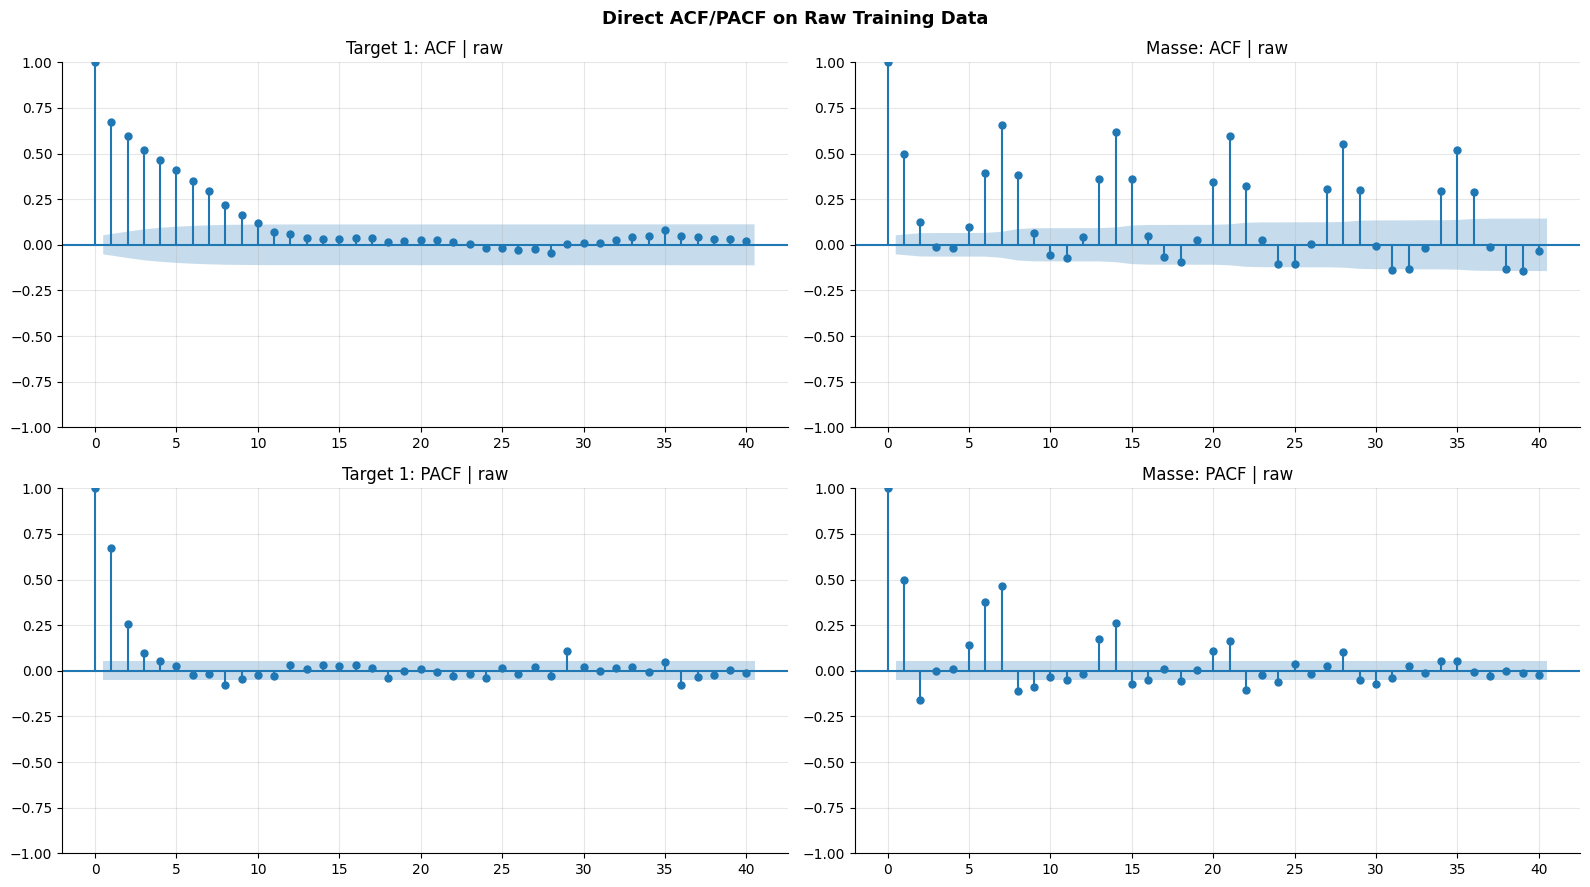

In [ ]:
y_train = train_raw[TARGET_COL].astype(float).values
masse_train = train_raw["Masse"].astype(float).values

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Direct ACF/PACF on Raw Training Data", fontsize=13, fontweight="bold")

plot_acf(y_train, ax=axes[0, 0], lags=40, title=f"Target {TARGET_COL}: ACF | raw")
plot_pacf(y_train, ax=axes[1, 0], lags=40, title=f"Target {TARGET_COL}: PACF | raw", method="ywm")

plot_acf(masse_train, ax=axes[0, 1], lags=40, title="Masse: ACF | raw")
plot_pacf(masse_train, ax=axes[1, 1], lags=40, title="Masse: PACF | raw", method="ywm")

for ax in axes.flat:
    ax.grid(True, alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/raw_acf_pacf_target_masse.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Extract important lags from raw ACF/PACF

This section turns the ACF/PACF inspection into a defensible lag-feature choice. The threshold is approximate: `±1.96 / sqrt(n)`.

In [ ]:
def get_significant_acf_pacf_lags(series, nlags=40):
    series = pd.Series(series).dropna().astype(float)
    n = len(series)
    threshold = 1.96 / np.sqrt(n)

    acf_values = acf(series, nlags=nlags, fft=True)
    pacf_values = pacf(series, nlags=nlags, method="ywm")

    sig_acf_lags = [lag for lag in range(1, nlags + 1) if abs(acf_values[lag]) > threshold]
    sig_pacf_lags = [lag for lag in range(1, nlags + 1) if abs(pacf_values[lag]) > threshold]

    summary = pd.DataFrame({
        "lag": range(1, nlags + 1),
        "acf": acf_values[1:],
        "pacf": pacf_values[1:],
        "significant_acf": [lag in sig_acf_lags for lag in range(1, nlags + 1)],
        "significant_pacf": [lag in sig_pacf_lags for lag in range(1, nlags + 1)],
    })

    return sig_acf_lags, sig_pacf_lags, threshold, summary

sig_acf_target, sig_pacf_target, threshold_target, lag_summary_target = get_significant_acf_pacf_lags(train_raw[TARGET_COL], nlags=40)
sig_acf_masse, sig_pacf_masse, threshold_masse, lag_summary_masse = get_significant_acf_pacf_lags(train_raw["Masse"], nlags=40)

print("Target significant ACF lags:", sig_acf_target[:20])
print("Target significant PACF lags:", sig_pacf_target[:20])
print("Masse significant ACF lags :", sig_acf_masse[:20])
print("Masse significant PACF lags:", sig_pacf_masse[:20])
print("Approx. significance threshold:", round(threshold_target, 5))

display(lag_summary_target.head(15))

Target significant ACF lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 35]
Target significant PACF lags: [1, 2, 3, 8, 29, 36]
Masse significant ACF lags : [1, 2, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 17, 18, 20, 21, 22, 24, 25, 27]
Masse significant PACF lags: [1, 2, 5, 6, 7, 8, 9, 11, 13, 14, 15, 18, 20, 21, 22, 24, 28, 30, 35]
Approx. significance threshold: 0.05238


,lag,acf,pacf,significant_acf,significant_pacf
0,1,0.675558,0.675558,True,True
1,2,0.594469,0.254018,True,True
2,3,0.519930,0.095843,True,True
3,4,0.462654,0.052098,True,False
4,5,0.411517,0.026329,True,False
5,6,0.347318,-0.024463,True,False
6,7,0.295749,-0.017778,True,False
7,8,0.218084,-0.077021,True,True
8,9,0.161721,-0.047148,True,False
9,10,0.116889,-0.022900,True,False


## 6. Create lag, calendar, Masse, and target features

These features are useful for feature diagnostics and future ML models. For SARIMAX, target lag columns are **not** used as exogenous variables because SARIMAX already models target autocorrelation internally through AR and seasonal terms. Using future target lags as external regressors in multi-step forecasting would cause leakage.

In [ ]:
def add_time_series_features(data, target_col=TARGET_COL):
    data = data.copy()

    # Clean input mass.
    data["Masse_clean"] = data["Masse"].clip(lower=0)

    # Fixed lag set based on practical interpretability and ACF/PACF inspection.
    # 1, 2, 3  -> short memory
    # 7     -> weekly effect
    # 14    -> two-week effect
    selected_lags = [1, 2,3, 7, 14]

    for lag in selected_lags:
        data[f"Masse_lag_{lag}"] = data["Masse_clean"].shift(lag)
        data[f"target_1_lag_{lag}"] = data[target_col].shift(lag)

    # Calendar features.
    data["month"] = data["Datum"].dt.month
    data["month_sin"] = np.sin(2 * np.pi * data["month"] / 12)
    data["month_cos"] = np.cos(2 * np.pi * data["month"] / 12)

    data["dayofweek"] = data["Datum"].dt.dayofweek
    data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)

    return data

feature_df = add_time_series_features(df, target_col=TARGET_COL)

lag_feature_cols = [
    "Masse_lag_1", "Masse_lag_2", "Masse_lag_3", "Masse_lag_7", "Masse_lag_14",
    "target_1_lag_1", "target_1_lag_2","target_1_lag_3", "target_1_lag_7", "target_1_lag_14",
]

calendar_feature_cols = ["month_sin", "month_cos", "dow_sin", "dow_cos"]
masse_feature_cols = ["Masse_clean"]

all_diagnostic_feature_cols = masse_feature_cols + lag_feature_cols + calendar_feature_cols

# Exogenous features for SARIMAX.
# Target lag columns are intentionally excluded to avoid future target leakage.
sarimax_exog_cols = [
    "Masse_clean",
    "Masse_lag_1", "Masse_lag_2","Masse_lag_3", "Masse_lag_7", "Masse_lag_14",
    "month_sin", "month_cos", "dow_sin", "dow_cos",
]

feature_model_df = feature_df.dropna(subset=all_diagnostic_feature_cols + [TARGET_COL]).reset_index(drop=True)

print("Diagnostic feature columns:")
print(all_diagnostic_feature_cols)
print()
print("SARIMAX exogenous columns:")
print(sarimax_exog_cols)
print()
print("Feature data range:", feature_model_df["Datum"].min(), "to", feature_model_df["Datum"].max())

Diagnostic feature columns:
['Masse_clean', 'Masse_lag_1', 'Masse_lag_2', 'Masse_lag_3', 'Masse_lag_7', 'Masse_lag_14', 'target_1_lag_1', 'target_1_lag_2', 'target_1_lag_3', 'target_1_lag_7', 'target_1_lag_14', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

SARIMAX exogenous columns:
['Masse_clean', 'Masse_lag_1', 'Masse_lag_2', 'Masse_lag_3', 'Masse_lag_7', 'Masse_lag_14', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']

Feature data range: 2020-03-16 00:00:00 to 2024-12-31 00:00:00


## 7. Feature diagnostics: relationship with target

,feature,corr_with_target,abs_corr
0,target_1_lag_1,0.457482,0.457482
1,target_1_lag_2,0.394992,0.394992
2,target_1_lag_3,0.354880,0.354880
3,target_1_lag_7,0.264244,0.264244
4,month_cos,0.118265,0.118265
5,target_1_lag_14,0.112580,0.112580
6,Masse_lag_3,0.072127,0.072127
7,Masse_clean,0.071403,0.071403
8,Masse_lag_2,0.066894,0.066894
9,Masse_lag_7,0.056978,0.056978


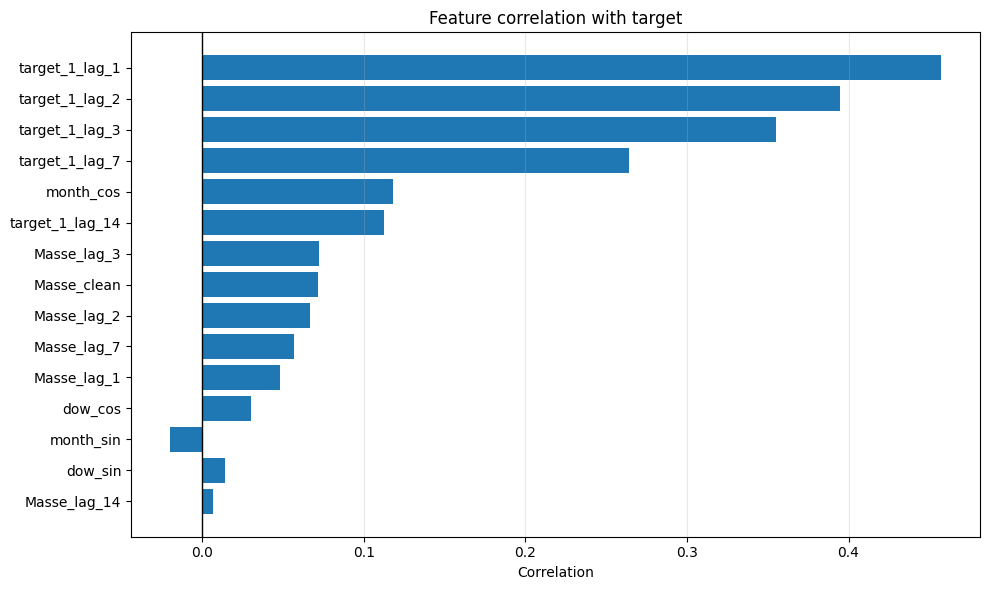

In [ ]:
# Simple correlation check between manually created features and target.
# This does not prove causality. It only helps identify useful candidate features.
correlation_rows = []

for col in all_diagnostic_feature_cols:
    corr = feature_model_df[[col, TARGET_COL]].corr().iloc[0, 1]
    correlation_rows.append({"feature": col, "corr_with_target": corr, "abs_corr": abs(corr)})

feature_corr_df = pd.DataFrame(correlation_rows).sort_values("abs_corr", ascending=False).reset_index(drop=True)

display(feature_corr_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_corr_df["feature"], feature_corr_df["corr_with_target"])
plt.axvline(0, color="black", lw=1)
plt.title("Feature correlation with target")
plt.xlabel("Correlation")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_target_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Baseline models and evaluation

Baselines are evaluated first because SARIMA/SARIMAX is only useful if it beats these simple references.

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_predictions(y_true, y_pred, model_name, horizon, evaluation):
    return {
        "Evaluation": evaluation,
        "Model": model_name,
        "Horizon": horizon,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
    }


def rolling_baseline_forecast(train_data, test_data, horizon, target_col=TARGET_COL):
    history = train_data.copy().reset_index(drop=True)
    test_data = test_data.copy().reset_index(drop=True)
    blocks = []

    start = 0
    while start < len(test_data):
        end = min(start + horizon, len(test_data))
        block = test_data.iloc[start:end].copy()
        h = len(block)

        y_hist = history[target_col].astype(float).values

        # 1. Naive: all future values equal the latest known value.
        block["Naive"] = y_hist[-1]

        # 2. Seasonal naive: repeat the last 7 values.
        last_season = y_hist[-SEASON:]
        block["SeasonalNaive"] = [last_season[i % SEASON] for i in range(h)]

        # 3. Historic average: all future values equal the training mean.
        block["HistoricAverage"] = np.mean(y_hist)

        # 4. Moving average over last 7 days.
        block["MovingAverage7"] = np.mean(y_hist[-7:])

        block["horizon"] = horizon
        blocks.append(block)

        # Rolling evaluation: after forecasting the block, actual values become available.
        history = pd.concat([history, block[history.columns]], ignore_index=True)
        start = end

    return pd.concat(blocks, ignore_index=True)


def make_cv_windows(data, horizon, n_windows):
    data = data.copy().reset_index(drop=True)
    total_validation = horizon * n_windows

    if len(data) <= total_validation:
        raise ValueError("Not enough training data for requested number of CV windows and horizon.")

    first_val_start = len(data) - total_validation

    for fold in range(n_windows):
        val_start = first_val_start + fold * horizon
        val_end = val_start + horizon
        train_fold = data.iloc[:val_start].copy()
        val_fold = data.iloc[val_start:val_end].copy()
        yield fold + 1, train_fold, val_fold


baseline_model_names = ["Naive", "SeasonalNaive", "HistoricAverage", "MovingAverage7"]

In [ ]:
# Test evaluation on full 2024 using rolling windows.
baseline_test_predictions = {}
baseline_test_results = []

for horizon in HORIZONS:
    pred_df = rolling_baseline_forecast(train_raw, test_raw, horizon, target_col=TARGET_COL)
    baseline_test_predictions[horizon] = pred_df

    for model in baseline_model_names:
        baseline_test_results.append(
            evaluate_predictions(pred_df[TARGET_COL], pred_df[model], model, horizon, "Test_2024")
        )

baseline_test_results_df = pd.DataFrame(baseline_test_results).sort_values(["Horizon", "MAE"]).reset_index(drop=True)
display(baseline_test_results_df)

baseline_test_results_df.to_csv(f"{OUTPUT_DIR}/baseline_test_2024_results.csv", index=False)

,Evaluation,Model,Horizon,MAE,RMSE
0,Test_2024,MovingAverage7,14,0.035916,0.069118
1,Test_2024,SeasonalNaive,14,0.047548,0.092703
2,Test_2024,HistoricAverage,14,0.047634,0.076727
3,Test_2024,Naive,14,0.093849,0.139517
4,Test_2024,MovingAverage7,30,0.037351,0.069891
5,Test_2024,Naive,30,0.042424,0.072157
6,Test_2024,HistoricAverage,30,0.047767,0.076836
7,Test_2024,SeasonalNaive,30,0.053121,0.104944


In [ ]:
# 5-fold CV baseline evaluation on training data only.
baseline_cv_results = []

for horizon in HORIZONS:
    for fold, train_fold, val_fold in make_cv_windows(train_raw, horizon, N_WINDOWS):
        pred_fold = rolling_baseline_forecast(train_fold, val_fold, horizon, target_col=TARGET_COL)

        for model in baseline_model_names:
            baseline_cv_results.append({
                "Evaluation": "CV",
                "Model": model,
                "Horizon": horizon,
                "Fold": fold,
                "MAE": mean_absolute_error(pred_fold[TARGET_COL], pred_fold[model]),
                "RMSE": rmse(pred_fold[TARGET_COL], pred_fold[model]),
            })

baseline_cv_results_df = pd.DataFrame(baseline_cv_results)

baseline_cv_summary_df = (
    baseline_cv_results_df
    .groupby(["Evaluation", "Model", "Horizon"], as_index=False)
    .agg(MAE=("MAE", "mean"), RMSE=("RMSE", "mean"))
    .sort_values(["Horizon", "MAE"])
    .reset_index(drop=True)
)

display(baseline_cv_summary_df)

baseline_cv_summary_df.to_csv(f"{OUTPUT_DIR}/baseline_cv_summary.csv", index=False)

,Evaluation,Model,Horizon,MAE,RMSE
0,CV,MovingAverage7,14,0.038845,0.054636
1,CV,HistoricAverage,14,0.041293,0.057115
2,CV,SeasonalNaive,14,0.050018,0.076705
3,CV,Naive,14,0.068437,0.081846
4,CV,HistoricAverage,30,0.037476,0.052996
5,CV,MovingAverage7,30,0.038920,0.055983
6,CV,Naive,30,0.042585,0.059501
7,CV,SeasonalNaive,30,0.043527,0.069815


## 9. SARIMA/SARIMAX model preparation

Two models are evaluated:

1. **SARIMA**: uses only the target series, fitted through the SARIMAX class without exogenous variables.
2. **SARIMAX**: uses the target series plus exogenous input/calendar features.

Because raw data is treated as stationary, `d=0` and `D=0` are used.

In [ ]:
# SARIMAX uses feature rows without missing exogenous values.
sx_df = feature_df.dropna(subset=sarimax_exog_cols + [TARGET_COL]).reset_index(drop=True)

sx_train = sx_df[(sx_df["Datum"] >= TRAIN_START) & (sx_df["Datum"] <= TRAIN_END)].copy()
sx_test = sx_df[(sx_df["Datum"] >= TEST_START) & (sx_df["Datum"] <= TEST_END)].copy()

print("SARIMAX train range:", sx_train["Datum"].min(), "to", sx_train["Datum"].max(), "| rows:", len(sx_train))
print("SARIMAX test range :", sx_test["Datum"].min(), "to", sx_test["Datum"].max(), "| rows:", len(sx_test))

# Candidate orders with d=0 and D=0 because we are not differencing.
ORDER_GRID = [
    (1, 0, 0),
    (2, 0, 0),
    (0, 0, 1),
    (1, 0, 1),
]

SEASONAL_ORDER_GRID = [
    (0, 0, 0, SEASON),
    (1, 0, 0, SEASON),
    (0, 0, 1, SEASON),
    (1, 0, 1, SEASON),
]

SARIMAX train range: 2020-03-16 00:00:00 to 2023-12-31 00:00:00 | rows: 1386
SARIMAX test range : 2024-01-01 00:00:00 to 2024-12-31 00:00:00 | rows: 366


## 10. Select SARIMA/SARIMAX orders by AIC

In [ ]:
def select_sarimax_order(train_data, exog_cols=None, maxiter=100):
    y = train_data[TARGET_COL].astype(float)
    exog = train_data[exog_cols].astype(float) if exog_cols is not None else None

    rows = []
    best = None

    for order in ORDER_GRID:
        for seasonal_order in SEASONAL_ORDER_GRID:
            try:
                model = SARIMAX(
                    y,
                    exog=exog,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                result = model.fit(disp=False, maxiter=maxiter)

                row = {
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "AIC": result.aic,
                    "BIC": result.bic,
                }
                rows.append(row)

                if best is None or result.aic < best["AIC"]:
                    best = row
            except Exception as e:
                rows.append({
                    "order": order,
                    "seasonal_order": seasonal_order,
                    "AIC": np.inf,
                    "BIC": np.inf,
                    "error": str(e)[:120],
                })

    result_df = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
    return best, result_df

print("Selecting SARIMA order without exogenous variables...")
best_sarima, sarima_aic_table = select_sarimax_order(sx_train, exog_cols=None, maxiter=100)
print("Best SARIMA:", best_sarima)
display(sarima_aic_table.head(10))

print()
print("Selecting SARIMAX order with exogenous variables...")
best_sarimax, sarimax_aic_table = select_sarimax_order(sx_train, exog_cols=sarimax_exog_cols, maxiter=100)
print("Best SARIMAX:", best_sarimax)
display(sarimax_aic_table.head(10))

sarima_aic_table.to_csv(f"{OUTPUT_DIR}/sarima_aic_table.csv", index=False)
sarimax_aic_table.to_csv(f"{OUTPUT_DIR}/sarimax_aic_table.csv", index=False)

Selecting SARIMA order without exogenous variables...
Best SARIMA: {'order': (1, 0, 1), 'seasonal_order': (1, 0, 0, 7), 'AIC': np.float64(-4201.70296899586), 'BIC': np.float64(-4175.561026737992)}


,order,seasonal_order,AIC,BIC
0,"(1, 0, 1)","(1, 0, 0, 7)",-4201.702969,-4175.561027
1,"(1, 0, 1)","(0, 0, 1, 7)",-4199.523440,-4173.385127
2,"(1, 0, 1)","(1, 0, 1, 7)",-4197.783010,-4166.417035
3,"(2, 0, 0)","(0, 0, 1, 7)",-4193.627332,-4167.485390
4,"(2, 0, 0)","(1, 0, 1, 7)",-4187.788710,-4156.422735
5,"(2, 0, 0)","(1, 0, 0, 7)",-4187.499994,-4161.361682
6,"(1, 0, 0)","(0, 0, 1, 7)",-4177.014764,-4156.101210
7,"(1, 0, 0)","(1, 0, 1, 7)",-4175.026058,-4148.884116
8,"(1, 0, 0)","(1, 0, 0, 7)",-4173.326804,-4152.413250
9,"(0, 0, 1)","(1, 0, 0, 7)",-4150.270045,-4129.353589



Selecting SARIMAX order with exogenous variables...


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best SARIMAX: {'order': (1, 0, 1), 'seasonal_order': (1, 0, 0, 7), 'AIC': np.float64(-4188.144602256298), 'BIC': np.float64(-4109.718775482694)}


,order,seasonal_order,AIC,BIC
0,"(1, 0, 1)","(1, 0, 0, 7)",-4188.144602,-4109.718775
1,"(1, 0, 1)","(0, 0, 1, 7)",-4186.096906,-4107.681969
2,"(2, 0, 0)","(0, 0, 1, 7)",-4180.463686,-4102.037860
3,"(1, 0, 1)","(1, 0, 1, 7)",-4175.676523,-4092.033923
4,"(2, 0, 0)","(1, 0, 1, 7)",-4174.163492,-4090.520892
5,"(2, 0, 0)","(1, 0, 0, 7)",-4174.130489,-4095.715552
6,"(1, 0, 0)","(0, 0, 1, 7)",-4164.672653,-4091.475214
7,"(1, 0, 0)","(1, 0, 1, 7)",-4162.681675,-4084.255849
8,"(1, 0, 0)","(1, 0, 0, 7)",-4160.883116,-4087.685677
9,"(0, 0, 1)","(1, 0, 0, 7)",-4140.326404,-4067.118809


## 11. SARIMA/SARIMAX rolling forecast functions

In [ ]:
def rolling_sarimax_forecast(train_data, test_data, horizon, order, seasonal_order, model_name, exog_cols=None, maxiter=150):
    history = train_data.copy().reset_index(drop=True)
    test_data = test_data.copy().reset_index(drop=True)
    blocks = []

    start = 0
    while start < len(test_data):
        end = min(start + horizon, len(test_data))
        block = test_data.iloc[start:end].copy()

        y_hist = history[TARGET_COL].astype(float)
        exog_hist = history[exog_cols].astype(float) if exog_cols is not None else None
        exog_future = block[exog_cols].astype(float) if exog_cols is not None else None

        try:
            model = SARIMAX(
                y_hist,
                exog=exog_hist,
                order=order,
                seasonal_order=seasonal_order,
                trend="c",
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            fitted = model.fit(disp=False, maxiter=maxiter)
            forecast = fitted.get_forecast(steps=len(block), exog=exog_future).predicted_mean
            block[model_name] = np.asarray(forecast)
        except Exception as e:
            print(f"{model_name} failed for block {start}:{end} | horizon={horizon} | error={e}")
            block[model_name] = np.nan

        block["horizon"] = horizon
        blocks.append(block)

        # Rolling update with actual test values after each forecast block.
        history = pd.concat([history, block[history.columns]], ignore_index=True)
        start = end

    return pd.concat(blocks, ignore_index=True)


def evaluate_model_forecasts(pred_df, pred_col, horizon, evaluation):
    valid = pred_df[[TARGET_COL, pred_col]].dropna()
    return evaluate_predictions(valid[TARGET_COL], valid[pred_col], pred_col, horizon, evaluation)

## 12. SARIMA/SARIMAX evaluation on full 2024 test set

In [ ]:
sarimax_test_predictions = {}
sarimax_test_results = []

sarima_order = best_sarima["order"]
sarima_seasonal_order = best_sarima["seasonal_order"]

sarimax_order = best_sarimax["order"]
sarimax_seasonal_order = best_sarimax["seasonal_order"]

for horizon in HORIZONS:
    print(f"Running SARIMA/SARIMAX rolling test evaluation | horizon={horizon}")

    pred_sarima = rolling_sarimax_forecast(
        train_data=sx_train,
        test_data=sx_test,
        horizon=horizon,
        order=sarima_order,
        seasonal_order=sarima_seasonal_order,
        model_name="SARIMA",
        exog_cols=None,
    )

    pred_sarimax = rolling_sarimax_forecast(
        train_data=sx_train,
        test_data=sx_test,
        horizon=horizon,
        order=sarimax_order,
        seasonal_order=sarimax_seasonal_order,
        model_name="SARIMAX",
        exog_cols=sarimax_exog_cols,
    )

    combined = pred_sarima[["Datum", TARGET_COL, "SARIMA", "horizon"]].copy()
    combined["SARIMAX"] = pred_sarimax["SARIMAX"].values
    sarimax_test_predictions[horizon] = combined

    sarimax_test_results.append(evaluate_model_forecasts(combined, "SARIMA", horizon, "Test_2024"))
    sarimax_test_results.append(evaluate_model_forecasts(combined, "SARIMAX", horizon, "Test_2024"))

sarimax_test_results_df = pd.DataFrame(sarimax_test_results).sort_values(["Horizon", "MAE"]).reset_index(drop=True)
display(sarimax_test_results_df)

sarimax_test_results_df.to_csv(f"{OUTPUT_DIR}/sarimax_test_2024_results.csv", index=False)

Running SARIMA/SARIMAX rolling test evaluation | horizon=14
Running SARIMA/SARIMAX rolling test evaluation | horizon=30


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Evaluation,Model,Horizon,MAE,RMSE
0,Test_2024,SARIMAX,14,0.037646,0.070042
1,Test_2024,SARIMA,14,0.038383,0.070222
2,Test_2024,SARIMAX,30,0.040886,0.071356
3,Test_2024,SARIMA,30,0.042121,0.071942


## 13. SARIMA/SARIMAX 5-fold CV on training data

In [ ]:
sarimax_cv_results = []

for horizon in HORIZONS:
    for fold, train_fold, val_fold in make_cv_windows(sx_train, horizon, N_WINDOWS):
        print(f"CV fold={fold} | horizon={horizon}")

        pred_sarima = rolling_sarimax_forecast(
            train_data=train_fold,
            test_data=val_fold,
            horizon=horizon,
            order=sarima_order,
            seasonal_order=sarima_seasonal_order,
            model_name="SARIMA",
            exog_cols=None,
            maxiter=100,
        )

        pred_sarimax = rolling_sarimax_forecast(
            train_data=train_fold,
            test_data=val_fold,
            horizon=horizon,
            order=sarimax_order,
            seasonal_order=sarimax_seasonal_order,
            model_name="SARIMAX",
            exog_cols=sarimax_exog_cols,
            maxiter=100,
        )

        sarimax_cv_results.append({
            "Evaluation": "CV",
            "Model": "SARIMA",
            "Horizon": horizon,
            "Fold": fold,
            "MAE": mean_absolute_error(pred_sarima[TARGET_COL], pred_sarima["SARIMA"]),
            "RMSE": rmse(pred_sarima[TARGET_COL], pred_sarima["SARIMA"]),
        })

        sarimax_cv_results.append({
            "Evaluation": "CV",
            "Model": "SARIMAX",
            "Horizon": horizon,
            "Fold": fold,
            "MAE": mean_absolute_error(pred_sarimax[TARGET_COL], pred_sarimax["SARIMAX"]),
            "RMSE": rmse(pred_sarimax[TARGET_COL], pred_sarimax["SARIMAX"]),
        })

sarimax_cv_results_df = pd.DataFrame(sarimax_cv_results)

sarimax_cv_summary_df = (
    sarimax_cv_results_df
    .groupby(["Evaluation", "Model", "Horizon"], as_index=False)
    .agg(MAE=("MAE", "mean"), RMSE=("RMSE", "mean"))
    .sort_values(["Horizon", "MAE"])
    .reset_index(drop=True)
)

display(sarimax_cv_summary_df)

sarimax_cv_summary_df.to_csv(f"{OUTPUT_DIR}/sarimax_cv_summary.csv", index=False)

CV fold=1 | horizon=14
CV fold=2 | horizon=14
CV fold=3 | horizon=14


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV fold=4 | horizon=14


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


CV fold=5 | horizon=14
CV fold=1 | horizon=30
CV fold=2 | horizon=30
CV fold=3 | horizon=30
CV fold=4 | horizon=30
CV fold=5 | horizon=30


,Evaluation,Model,Horizon,MAE,RMSE
0,CV,SARIMAX,14,0.038543,0.054468
1,CV,SARIMA,14,0.040378,0.055729
2,CV,SARIMAX,30,0.039372,0.055100
3,CV,SARIMA,30,0.039703,0.055289


## 14. Final comparison: baselines vs SARIMA/SARIMAX

In [ ]:
final_test_comparison = pd.concat(
    [baseline_test_results_df, sarimax_test_results_df],
    ignore_index=True
).sort_values(["Horizon", "MAE"]).reset_index(drop=True)

final_cv_comparison = pd.concat(
    [baseline_cv_summary_df, sarimax_cv_summary_df],
    ignore_index=True
).sort_values(["Horizon", "MAE"]).reset_index(drop=True)

print("Final 2024 Test Comparison")
display(final_test_comparison)

print("Final 5-Fold CV Comparison")
display(final_cv_comparison)

final_test_comparison.to_csv(f"{OUTPUT_DIR}/final_test_comparison.csv", index=False)
final_cv_comparison.to_csv(f"{OUTPUT_DIR}/final_cv_comparison.csv", index=False)

Final 2024 Test Comparison


,Evaluation,Model,Horizon,MAE,RMSE
0,Test_2024,MovingAverage7,14,0.035916,0.069118
1,Test_2024,SARIMAX,14,0.037646,0.070042
2,Test_2024,SARIMA,14,0.038383,0.070222
3,Test_2024,SeasonalNaive,14,0.047548,0.092703
4,Test_2024,HistoricAverage,14,0.047634,0.076727
5,Test_2024,Naive,14,0.093849,0.139517
6,Test_2024,MovingAverage7,30,0.037351,0.069891
7,Test_2024,SARIMAX,30,0.040886,0.071356
8,Test_2024,SARIMA,30,0.042121,0.071942
9,Test_2024,Naive,30,0.042424,0.072157


Final 5-Fold CV Comparison


,Evaluation,Model,Horizon,MAE,RMSE
0,CV,SARIMAX,14,0.038543,0.054468
1,CV,MovingAverage7,14,0.038845,0.054636
2,CV,SARIMA,14,0.040378,0.055729
3,CV,HistoricAverage,14,0.041293,0.057115
4,CV,SeasonalNaive,14,0.050018,0.076705
5,CV,Naive,14,0.068437,0.081846
6,CV,HistoricAverage,30,0.037476,0.052996
7,CV,MovingAverage7,30,0.038920,0.055983
8,CV,SARIMAX,30,0.039372,0.055100
9,CV,SARIMA,30,0.039703,0.055289


## 15. Plot final forecasts for one horizon

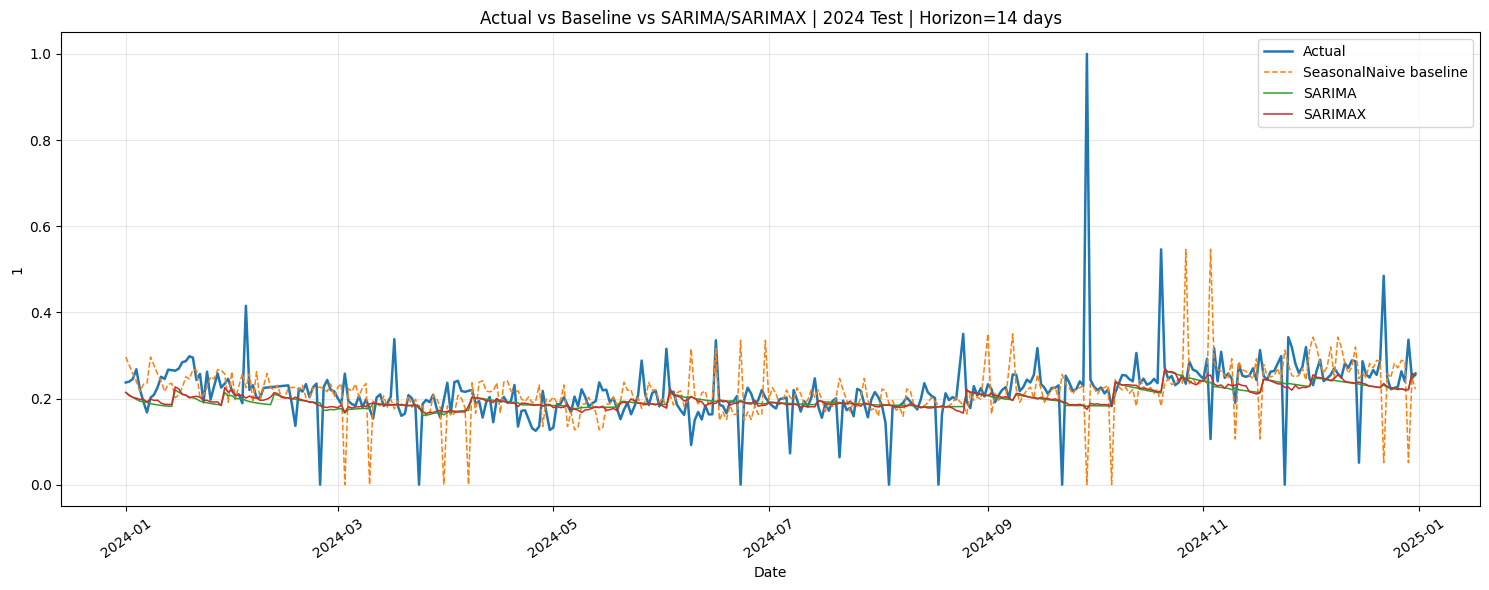

In [ ]:
plot_horizon = 14
plot_df = sarimax_test_predictions[plot_horizon].copy()
base_plot_df = baseline_test_predictions[plot_horizon].copy()

plt.figure(figsize=(15, 6))
plt.plot(plot_df["Datum"], plot_df[TARGET_COL], label="Actual", lw=1.8)
plt.plot(base_plot_df["Datum"], base_plot_df["SeasonalNaive"], label="SeasonalNaive baseline", lw=1.1, linestyle="--")
plt.plot(plot_df["Datum"], plot_df["SARIMA"], label="SARIMA", lw=1.1)
plt.plot(plot_df["Datum"], plot_df["SARIMAX"], label="SARIMAX", lw=1.1)
plt.title(f"Actual vs Baseline vs SARIMA/SARIMAX | 2024 Test | Horizon={plot_horizon} days")
plt.xlabel("Date")
plt.ylabel(TARGET_COL)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/forecast_comparison_horizon_{plot_horizon}.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Summary

In [ ]:
print("=" * 80)
print("PIPELINE SUMMARY")
print("=" * 80)
print(f"Target column      : {TARGET_COL}")
print(f"Train period       : {train_raw['Datum'].min().date()} to {train_raw['Datum'].max().date()}")
print(f"Test period        : {test_raw['Datum'].min().date()} to {test_raw['Datum'].max().date()}")
print(f"Horizons           : {HORIZONS}")
print(f"CV folds           : {N_WINDOWS}")
print("Differencing       : Not applied")
print("Decomposition      : Not applied")
print("ACF/PACF           : Applied directly on raw target")
print()
print("Best 2024 test model by horizon:")
for horizon in HORIZONS:
    row = final_test_comparison[final_test_comparison["Horizon"] == horizon].sort_values("MAE").iloc[0]
    print(f"  H={horizon:<2}: {row['Model']} | MAE={row['MAE']:.5f} | RMSE={row['RMSE']:.5f}")
print()
print("Best CV model by horizon:")
for horizon in HORIZONS:
    row = final_cv_comparison[final_cv_comparison["Horizon"] == horizon].sort_values("MAE").iloc[0]
    print(f"  H={horizon:<2}: {row['Model']} | MAE={row['MAE']:.5f} | RMSE={row['RMSE']:.5f}")
print("=" * 80)

PIPELINE SUMMARY
Target column      : 1
Train period       : 2020-03-02 to 2023-12-31
Test period        : 2024-01-01 to 2024-12-31
Horizons           : [14, 30]
CV folds           : 5
Differencing       : Not applied
Decomposition      : Not applied
ACF/PACF           : Applied directly on raw target

Best 2024 test model by horizon:
  H=14: MovingAverage7 | MAE=0.03592 | RMSE=0.06912
  H=30: MovingAverage7 | MAE=0.03735 | RMSE=0.06989

Best CV model by horizon:
  H=14: SARIMAX | MAE=0.03854 | RMSE=0.05447
  H=30: HistoricAverage | MAE=0.03748 | RMSE=0.05300
